# Phase 5: Explainable AI for Quantitative DDI LD50 Prediction

This notebook applies multiple explainability methods to understand why the selected Phase 4 model predicts a particular mixture toxicity value for a pair of drugs. The goal is to produce chemically meaningful explanations by identifying the atoms and fragments that contribute most strongly to the predicted LD50 toxicity.

## Main steps

1. **Load the best Phase 4 regression model**  
   The selected dual-encoder regression model and its transferred encoder are reloaded so that explanations are generated from the final toxicity predictor.

2. **Load the unified mixture toxicity dataset and metadata**  
   The graph pairs, toxicity targets, scaler, and processed metadata are loaded to allow both prediction and mapping back to drug names and molecular structures.

3. **Recreate the Phase 4 test split**  
   The same held-out test split is reconstructed so that explainability benchmarking is performed on unseen samples.

4. **Implement multiple suitable XAI methods**  
   Several atom-level explainers are compared, including Saliency, Gradient x Input, Integrated Gradients, SmoothGrad, and Feature Ablation.

5. **Benchmark all XAI methods**  
   Each method is evaluated using explanation-quality criteria such as faithfulness, stability, and sanity.

6. **Select the best XAI method**  
   The final explainer is chosen based on its overall benchmark performance rather than by assuming a single method in advance.

7. **Explain a target drug pair**  
   The selected XAI method is used to explain a specific pair, such as Morpholine + Toluene, by identifying the most influential atoms and fragments in both drugs.

8. **Visualize and summarize explanations**  
   Molecule drawings, atom-importance bar charts, fragment extraction, and textual summaries are used to present the explanation clearly.

The notebook produces:
- a benchmark comparison of XAI methods
- the selected best explainer
- atom-level and fragment-level explanations for the target pair
- saved explanation summaries for reporting and discussion

In [1]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric
!pip install captum
!pip install pubchempy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import copy
import random
import joblib
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

import pubchempy as pcp

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Change this to your own local folder
base_path = r'C:\Users\msi\Downloads\IRP Jupiter nb\Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

best_reg_model_path = os.path.join(processed_dir, 'best_ddi_reg_model.pt')
best_reg_encoder_path = os.path.join(processed_dir, 'best_ddi_reg_encoder.pt')
mixture_raw_path = os.path.join(processed_dir, 'unified_mixture_toxicity.pt')
mixture_scaled_path = os.path.join(processed_dir, 'unified_mixture_toxicity_scaled.pt')
mixture_scaler_path = os.path.join(processed_dir, 'mixture_toxicity_scaler.pkl')
mixture_csv_path = os.path.join(base_path, 'unified_mixture_toxicity_processed.csv')

print("best_reg_model_path:", best_reg_model_path)
print("mixture_raw_path:", mixture_raw_path)
print("mixture_scaled_path:", mixture_scaled_path)
print("mixture_scaler_path:", mixture_scaler_path)
print("mixture_csv_path:", mixture_csv_path)

Using device: cuda
best_reg_model_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_reg_model.pt
mixture_raw_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity.pt
mixture_scaled_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity_scaled.pt
mixture_scaler_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\mixture_toxicity_scaler.pkl
mixture_csv_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\unified_mixture_toxicity_processed.csv


## Reproducibility

Keeps the explainability benchmark stable and reproducible.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Phase 4 encoder classes

The encoder must exactly match the architecture used in the current Phase 4 workflow.

In [5]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder

## Phase 4 regression heads

The explainability stage must rebuild the exact regression head selected in Phase 4.

In [6]:
class DualEncoderConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        fused = torch.cat([emb_a, emb_b], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        fused = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderBilinearConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.bilinear = nn.Bilinear(emb_dim, emb_dim, emb_dim)
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        bilinear_term = self.bilinear(emb_a, emb_b)
        fused = torch.cat([emb_a, emb_b, prod, bilinear_term], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderAbsDiffConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        abs_diff = torch.abs(emb_a - emb_b)
        fused = torch.cat([emb_a, emb_b, abs_diff], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderSymmetricFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        emb_sum = emb_a + emb_b
        abs_diff = torch.abs(emb_a - emb_b)
        prod = emb_a * emb_b
        fused = torch.cat([emb_sum, abs_diff, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderGatedFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        gate = self.gate(torch.cat([emb_a, emb_b], dim=1))
        fused_main = gate * emb_a + (1.0 - gate) * emb_b
        prod = emb_a * emb_b
        fused = torch.cat([fused_main, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


def build_regression_model(model_name, encoder_meta, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatRegressor":
        return DualEncoderConcatRegressor(encoder, dropout=dropout)
    elif model_name == "ConcatProdRegressor":
        return DualEncoderConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "BilinearConcatProdRegressor":
        return DualEncoderBilinearConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "AbsDiffConcatRegressor":
        return DualEncoderAbsDiffConcatRegressor(encoder, dropout=dropout)
    elif model_name == "SymmetricFusionRegressor":
        return DualEncoderSymmetricFusionRegressor(encoder, dropout=dropout)
    elif model_name == "GatedFusionRegressor":
        return DualEncoderGatedFusionRegressor(encoder, dropout=dropout)
    else:
        raise ValueError(f"Unknown regression model: {model_name}")

## Load Phase 4 model metadata and rebuild the trained model

This guarantees that explanations are produced for the exact model selected in Phase 4.

In [7]:
phase4_meta = torch.load(
    best_reg_model_path,
    map_location='cpu',
    weights_only=False
)

print("Loaded Phase 4 model info:")
print("Selected model:", phase4_meta["model_name"])
print("Best validation MAE:", phase4_meta["best_val_mae"])
print("Best epoch:", phase4_meta["best_epoch"])

model = build_regression_model(
    model_name=phase4_meta["model_name"],
    encoder_meta=phase4_meta["encoder_meta"],
    dropout=phase4_meta["dropout"]
).to(device)

model.load_state_dict(phase4_meta["model_state_dict"])
model.eval()

print("Phase 4 regression model loaded successfully.")

Loaded Phase 4 model info:
Selected model: SymmetricFusionRegressor
Best validation MAE: 0.28182182
Best epoch: 69
Phase 4 regression model loaded successfully.


## Load graph datasets and scaler safely

We need graph pairs for explanation, raw targets for interpretation, and a scaler for inverse transformation.

In [8]:
raw_data = torch.load(mixture_raw_path, map_location='cpu', weights_only=False)
scaled_data = torch.load(mixture_scaled_path, map_location='cpu', weights_only=False)

graphs_a_raw, graphs_b_raw, targets_raw = raw_data
graphs_a_scaled, graphs_b_scaled, targets_scaled = scaled_data

if torch.is_tensor(targets_raw):
    targets_raw = targets_raw.view(-1).float()
else:
    targets_raw = torch.tensor(targets_raw, dtype=torch.float)

if torch.is_tensor(targets_scaled):
    targets_scaled = targets_scaled.view(-1).float()
else:
    targets_scaled = torch.tensor(targets_scaled, dtype=torch.float)

try:
    mixture_scaler = joblib.load(mixture_scaler_path)
    print("Scaler loaded successfully.")
except Exception:
    print("Scaler load failed. Rebuilding scaler from raw targets...")
    mixture_scaler = StandardScaler()
    mixture_scaler.fit(targets_raw.cpu().numpy().reshape(-1, 1))

print("Number of graph pairs:", len(graphs_a_raw))
print("Raw target range:", float(targets_raw.min()), "to", float(targets_raw.max()))
print("Scaled target mean:", float(targets_scaled.mean()))
print("Scaled target std:", float(targets_scaled.std()))

Scaler load failed. Rebuilding scaler from raw targets...
Number of graph pairs: 387
Raw target range: 0.14688006043434143 to 4.539128303527832
Scaled target mean: 1.7711974109602124e-09
Scaled target std: 1.001294493675232


## Load processed metadata CSV

This lets you map graph indices back to drug names, sources, and SMILES strings.

In [9]:
df_meta = pd.read_csv(mixture_csv_path)
print("Metadata shape:", df_meta.shape)
display(df_meta.head())

# Ensure required columns exist
required_cols = ["SMILES_A", "SMILES_B", "Target_neglog_molkg"]
for col in required_cols:
    if col not in df_meta.columns:
        raise ValueError(f"Missing required column: {col}")

# Create fallback name columns if they do not exist
if "DrugA" not in df_meta.columns:
    df_meta["DrugA"] = [f"Drug_A_{i}" for i in range(len(df_meta))]

if "DrugB" not in df_meta.columns:
    df_meta["DrugB"] = [f"Drug_B_{i}" for i in range(len(df_meta))]

if "source" not in df_meta.columns:
    df_meta["source"] = "Unknown"

print("Columns available:")
print(df_meta.columns.tolist())

Metadata shape: (387, 5)


,PairKey,SMILES_A,SMILES_B,Target_neglog_molkg,source
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1||CCCCC...,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312,Acute_Oral_Toxicity
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102,Acute_Oral_Toxicity
3,C1COCCN1||C1COCCO1,C1COCCN1,C1COCCO1,1.359363,Smyth
4,C1COCCN1||C=CC#N,C1COCCN1,C=CC#N,2.130152,Smyth


Columns available:
['PairKey', 'SMILES_A', 'SMILES_B', 'Target_neglog_molkg', 'source', 'DrugA', 'DrugB']


## Recreate the same test split as Phase 4

The explainability benchmark should be run on the same held-out test portion used in Phase 4.

In [10]:
def make_regression_bins(y, n_bins=5):
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.array(y)
    bins = pd.qcut(y_np, q=n_bins, labels=False, duplicates='drop')
    return np.asarray(bins)

bins = make_regression_bins(targets_scaled, n_bins=5)
all_indices = np.arange(len(targets_scaled))

splitter_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(splitter_1.split(all_indices, bins))

splitter_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_sub_idx, val_sub_idx = next(splitter_2.split(train_val_idx, bins[train_val_idx]))

train_idx = train_val_idx[train_sub_idx]
val_idx = train_val_idx[val_sub_idx]

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 270
Validation size: 58
Test size: 59


## Basic prediction helpers

These helper functions simplify prediction and inverse transformation.

In [11]:
def prepare_single_graph(g, device):
    g = g.clone().to(device)
    g.batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    return g

def predict_scaled(model, graph_a, graph_b):
    model.eval()
    with torch.no_grad():
        out, _ = model(graph_a, graph_b)
    return float(out.view(-1)[0].item())

def predict_original(model, graph_a, graph_b, scaler):
    pred_scaled = predict_scaled(model, graph_a, graph_b)
    pred_original = scaler.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
    return float(pred_original)

def classify_toxicity_level(pred_pld50):
    if pred_pld50 >= 3.5:
        return "extremely highly toxic"
    elif pred_pld50 >= 3.0:
        return "very highly toxic"
    elif pred_pld50 >= 2.5:
        return "highly toxic"
    elif pred_pld50 >= 2.0:
        return "moderately toxic"
    elif pred_pld50 >= 1.5:
        return "mildly toxic"
    else:
        return "very mildly toxic"

## Utility functions for explainers

These helpers make all explainers compatible with your dual-encoder graph regression model.

In [12]:
def clone_graph_with_x(graph, new_x):
    g = graph.clone()
    g.x = new_x
    if not hasattr(g, "batch") or g.batch is None:
        g.batch = torch.zeros(g.x.size(0), dtype=torch.long, device=g.x.device)
    return g

def forward_from_x(model, graph_a, graph_b, x_a, x_b):
    g_a = clone_graph_with_x(graph_a, x_a)
    g_b = clone_graph_with_x(graph_b, x_b)
    pred, _ = model(g_a, g_b)
    return pred.view(-1).sum()

def normalize_importance(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

def safe_pearson(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(pearsonr(a, b)[0])

## XAI methods

These are suitable explainers for your dual-graph regression setting:

- Saliency: fast first-order gradient explanation
- Gradient x Input: accounts for both sensitivity and feature magnitude
- Integrated Gradients: more stable path-based attribution
- SmoothGrad: averages noisy gradients for more robust saliency
- Feature Ablation: perturbation-based, easy to interpret chemically

In [13]:
def explain_saliency(model, graph_a, graph_b, device):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device).requires_grad_(True)
    x_b = graph_b.x.clone().detach().to(device).requires_grad_(True)

    pred = forward_from_x(model, graph_a, graph_b, x_a, x_b)
    model.zero_grad()
    pred.backward()

    imp_a = x_a.grad.detach().abs().sum(dim=1).cpu().numpy()
    imp_b = x_b.grad.detach().abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_grad_input(model, graph_a, graph_b, device):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device).requires_grad_(True)
    x_b = graph_b.x.clone().detach().to(device).requires_grad_(True)

    pred = forward_from_x(model, graph_a, graph_b, x_a, x_b)
    model.zero_grad()
    pred.backward()

    imp_a = (x_a.grad.detach() * x_a.detach()).abs().sum(dim=1).cpu().numpy()
    imp_b = (x_b.grad.detach() * x_b.detach()).abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_integrated_gradients(model, graph_a, graph_b, device, steps=40):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device)
    x_b = graph_b.x.clone().detach().to(device)

    baseline_a = torch.zeros_like(x_a)
    baseline_b = torch.zeros_like(x_b)

    total_grad_a = torch.zeros_like(x_a)
    total_grad_b = torch.zeros_like(x_b)

    for alpha in np.linspace(0.0, 1.0, steps):
        x_interp_a = (baseline_a + alpha * (x_a - baseline_a)).detach().requires_grad_(True)
        x_interp_b = (baseline_b + alpha * (x_b - baseline_b)).detach().requires_grad_(True)

        pred = forward_from_x(model, graph_a, graph_b, x_interp_a, x_interp_b)
        model.zero_grad()
        pred.backward()

        total_grad_a += x_interp_a.grad.detach()
        total_grad_b += x_interp_b.grad.detach()

    avg_grad_a = total_grad_a / steps
    avg_grad_b = total_grad_b / steps

    attr_a = (x_a - baseline_a) * avg_grad_a
    attr_b = (x_b - baseline_b) * avg_grad_b

    imp_a = attr_a.abs().sum(dim=1).cpu().numpy()
    imp_b = attr_b.abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_smoothgrad(model, graph_a, graph_b, device, n_samples=20, noise_std=0.02):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device)
    x_b = graph_b.x.clone().detach().to(device)

    total_imp_a = np.zeros(x_a.size(0), dtype=float)
    total_imp_b = np.zeros(x_b.size(0), dtype=float)

    for _ in range(n_samples):
        noisy_a = (x_a + torch.randn_like(x_a) * noise_std).detach().requires_grad_(True)
        noisy_b = (x_b + torch.randn_like(x_b) * noise_std).detach().requires_grad_(True)

        pred = forward_from_x(model, graph_a, graph_b, noisy_a, noisy_b)
        model.zero_grad()
        pred.backward()

        total_imp_a += noisy_a.grad.detach().abs().sum(dim=1).cpu().numpy()
        total_imp_b += noisy_b.grad.detach().abs().sum(dim=1).cpu().numpy()

    imp_a = total_imp_a / n_samples
    imp_b = total_imp_b / n_samples
    return imp_a, imp_b


def explain_feature_ablation(model, graph_a, graph_b, device):
    model.eval()

    pred_orig = predict_scaled(model, graph_a, graph_b)
    imp_a = np.zeros(graph_a.x.size(0), dtype=float)
    imp_b = np.zeros(graph_b.x.size(0), dtype=float)

    for i in range(graph_a.x.size(0)):
        g_a_masked = graph_a.clone()
        g_a_masked.x[i] = torch.zeros_like(g_a_masked.x[i])
        pred_masked = predict_scaled(model, g_a_masked, graph_b)
        imp_a[i] = abs(pred_orig - pred_masked)

    for i in range(graph_b.x.size(0)):
        g_b_masked = graph_b.clone()
        g_b_masked.x[i] = torch.zeros_like(g_b_masked.x[i])
        pred_masked = predict_scaled(model, graph_a, g_b_masked)
        imp_b[i] = abs(pred_orig - pred_masked)

    return imp_a, imp_b


EXPLAINERS = {
    "Saliency": explain_saliency,
    "GradInput": explain_grad_input,
    "IntegratedGradients": explain_integrated_gradients,
    "SmoothGrad": explain_smoothgrad,
    "FeatureAblation": explain_feature_ablation,
}

## Explanation quality metrics

To choose the best XAI method, we evaluate each explainer using:

- Faithfulness: top-ranked atoms should change the prediction more than random atoms
- Stability: small input noise should not drastically change the explanation
- Sanity: explanations should depend on learned model parameters

In [14]:
def get_combined_importance(imp_a, imp_b):
    return np.concatenate([np.asarray(imp_a), np.asarray(imp_b)])

def remove_top_atoms_and_measure(model, graph_a, graph_b, imp_a, imp_b, top_k=5, random_runs=10):
    pred_orig = predict_scaled(model, graph_a, graph_b)

    combined = []
    for i, v in enumerate(imp_a):
        combined.append(("A", i, float(v)))
    for i, v in enumerate(imp_b):
        combined.append(("B", i, float(v)))

    combined_sorted = sorted(combined, key=lambda x: x[2], reverse=True)
    combined_indices = [(x[0], x[1]) for x in combined_sorted]

    max_steps = min(top_k, len(combined_indices))

    drops_top = []
    for k in range(1, max_steps + 1):
        g_a = graph_a.clone()
        g_b = graph_b.clone()
        for side, idx in combined_indices[:k]:
            if side == "A":
                g_a.x[idx] = torch.zeros_like(g_a.x[idx])
            else:
                g_b.x[idx] = torch.zeros_like(g_b.x[idx])
        pred_k = predict_scaled(model, g_a, g_b)
        drops_top.append(abs(pred_orig - pred_k))

    drops_random_runs = []
    for _ in range(random_runs):
        shuffled = combined_indices.copy()
        random.shuffle(shuffled)
        drops_rand = []
        for k in range(1, max_steps + 1):
            g_a = graph_a.clone()
            g_b = graph_b.clone()
            for side, idx in shuffled[:k]:
                if side == "A":
                    g_a.x[idx] = torch.zeros_like(g_a.x[idx])
                else:
                    g_b.x[idx] = torch.zeros_like(g_b.x[idx])
            pred_k = predict_scaled(model, g_a, g_b)
            drops_rand.append(abs(pred_orig - pred_k))
        drops_random_runs.append(drops_rand)

    drops_rand_mean = np.mean(drops_random_runs, axis=0)
    aopc_top = float(np.mean(drops_top))
    aopc_rand = float(np.mean(drops_rand_mean))
    faithfulness_gain = aopc_top - aopc_rand

    return {
        "aopc_top": aopc_top,
        "aopc_random": aopc_rand,
        "faithfulness_gain": faithfulness_gain
    }

def stability_score(model, graph_a, graph_b, explainer_fn, device, noise_std=0.01, runs=5):
    imp_a_orig, imp_b_orig = explainer_fn(model, graph_a, graph_b, device)
    imp_orig = get_combined_importance(normalize_importance(imp_a_orig), normalize_importance(imp_b_orig))

    corrs = []
    for _ in range(runs):
        g_a = graph_a.clone()
        g_b = graph_b.clone()
        g_a.x = g_a.x + torch.randn_like(g_a.x) * noise_std
        g_b.x = g_b.x + torch.randn_like(g_b.x) * noise_std

        imp_a_noisy, imp_b_noisy = explainer_fn(model, g_a, g_b, device)
        imp_noisy = get_combined_importance(normalize_importance(imp_a_noisy), normalize_importance(imp_b_noisy))
        corrs.append(safe_pearson(imp_orig, imp_noisy))

    return float(np.mean(corrs))

def randomize_model_weights(model):
    rand_model = copy.deepcopy(model)
    for module in rand_model.modules():
        if hasattr(module, 'reset_parameters'):
            try:
                module.reset_parameters()
            except Exception:
                pass
    return rand_model

def sanity_score(model, graph_a, graph_b, explainer_fn, device):
    imp_a_orig, imp_b_orig = explainer_fn(model, graph_a, graph_b, device)
    imp_orig = get_combined_importance(normalize_importance(imp_a_orig), normalize_importance(imp_b_orig))

    rand_model = randomize_model_weights(model).to(device)
    rand_model.eval()

    imp_a_rand, imp_b_rand = explainer_fn(rand_model, graph_a, graph_b, device)
    imp_rand = get_combined_importance(normalize_importance(imp_a_rand), normalize_importance(imp_b_rand))

    corr = safe_pearson(imp_orig, imp_rand)
    return float(1.0 - abs(corr))

## Build a small benchmark subset from the Phase 4 test split

Running every explainer on every sample is slow. This benchmark uses a small, reproducible subset of unseen test pairs.

In [15]:
rng = np.random.default_rng(42)
benchmark_size = min(12, len(test_idx))
benchmark_indices = rng.choice(test_idx, size=benchmark_size, replace=False)

print("Benchmark indices:", benchmark_indices)

Benchmark indices: [  4 131 172  17  46 372 162 279 365 240 118 160]


## Benchmark all XAI methods and choose the best one

This is the key selection stage. We compare explainers using quantitative explanation-quality measures.

In [16]:
benchmark_rows = []

for method_name, explainer_fn in EXPLAINERS.items():
    print(f"\nRunning XAI benchmark for: {method_name}")

    faithfulness_scores = []
    stability_scores = []
    sanity_scores = []

    for idx in benchmark_indices:
        g_a = prepare_single_graph(graphs_a_raw[idx], device)
        g_b = prepare_single_graph(graphs_b_raw[idx], device)

        imp_a, imp_b = explainer_fn(model, g_a, g_b, device)

        faith = remove_top_atoms_and_measure(
            model, g_a, g_b, imp_a, imp_b,
            top_k=min(5, g_a.x.size(0) + g_b.x.size(0)),
            random_runs=5
        )
        stab = stability_score(model, g_a, g_b, explainer_fn, device, noise_std=0.01, runs=3)
        san = sanity_score(model, g_a, g_b, explainer_fn, device)

        faithfulness_scores.append(faith["faithfulness_gain"])
        stability_scores.append(stab)
        sanity_scores.append(san)

    benchmark_rows.append({
        "method": method_name,
        "faithfulness_gain": np.mean(faithfulness_scores),
        "stability": np.mean(stability_scores),
        "sanity": np.mean(sanity_scores)
    })

xai_results = pd.DataFrame(benchmark_rows)
xai_results


Running XAI benchmark for: Saliency

Running XAI benchmark for: GradInput

Running XAI benchmark for: IntegratedGradients

Running XAI benchmark for: SmoothGrad

Running XAI benchmark for: FeatureAblation


,method,faithfulness_gain,stability,sanity
0,Saliency,0.171806,0.921874,0.415465
1,GradInput,0.224394,0.822306,0.751906
2,IntegratedGradients,0.290736,0.995764,0.507926
3,SmoothGrad,0.283002,0.962284,0.405044
4,FeatureAblation,0.424964,0.982788,0.730575


## Compute composite ranking and select the best explainer

Combine the metrics into one overall ranking.

In [17]:
def minmax_col(s):
    s = pd.Series(s)
    if s.max() - s.min() < 1e-12:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

xai_results["faithfulness_norm"] = minmax_col(xai_results["faithfulness_gain"])
xai_results["stability_norm"] = minmax_col(xai_results["stability"])
xai_results["sanity_norm"] = minmax_col(xai_results["sanity"])

# Higher faithfulness is most important
xai_results["composite_score"] = (
    0.50 * xai_results["faithfulness_norm"] +
    0.30 * xai_results["stability_norm"] +
    0.20 * xai_results["sanity_norm"]
)

xai_results = xai_results.sort_values("composite_score", ascending=False).reset_index(drop=True)
xai_results

,method,faithfulness_gain,stability,sanity,faithfulness_norm,stability_norm,sanity_norm,composite_score
0,FeatureAblation,0.424964,0.982788,0.730575,1.000000,0.925192,0.938504,0.965258
1,IntegratedGradients,0.290736,0.995764,0.507926,0.469785,1.000000,0.296610,0.594215
2,SmoothGrad,0.283002,0.962284,0.405044,0.439237,0.806984,0.000000,0.461714
3,GradInput,0.224394,0.822306,0.751906,0.207728,0.000000,1.000000,0.303864
4,Saliency,0.171806,0.921874,0.415465,0.000000,0.574015,0.030045,0.178214


## Save XAI comparison results

Stores the explainer benchmark for reporting.

In [18]:
xai_comparison_path = os.path.join(processed_dir, "phase5_xai_method_comparison.csv")
xai_results.to_csv(xai_comparison_path, index=False)
print("Saved XAI comparison table to:", xai_comparison_path)

best_xai_method = xai_results.loc[0, "method"]
best_explainer_fn = EXPLAINERS[best_xai_method]

print("Selected XAI method:", best_xai_method)

Saved XAI comparison table to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\phase5_xai_method_comparison.csv
Selected XAI method: FeatureAblation


## Brief interpretation of explainer selection

In [19]:
print("Best XAI method selected:", best_xai_method)
print(xai_results[["method", "faithfulness_gain", "stability", "sanity", "composite_score"]])

if best_xai_method == "FeatureAblation":
    print("\nFeatureAblation was selected because it achieved the strongest overall explanation quality. "
          "Its higher faithfulness suggests that the highlighted atoms had a real effect on the prediction, "
          "while its stability and sanity results indicate that the explanations were robust and model-specific.")
elif best_xai_method == "IntegratedGradients":
    print("\nIntegratedGradients was selected because it produced the best overall balance of faithfulness, "
          "stability, and sanity. This suggests that path-based gradient attribution captured meaningful and "
          "consistent atomic contributions to mixture toxicity.")
elif best_xai_method == "GradInput":
    print("\nGradInput was selected because it provided the strongest overall explanation quality. "
          "This suggests that weighting gradients by the original input values helped identify the most influential atomic features.")
elif best_xai_method == "Saliency":
    print("\nSaliency was selected because it achieved the best overall explanation quality. "
          "This suggests that first-order gradients alone were sufficient to capture the main atomic drivers of the prediction.")
elif best_xai_method == "SmoothGrad":
    print("\nSmoothGrad was selected because it achieved the best overall explanation quality. "
          "This suggests that averaging gradients across noisy inputs improved robustness and reduced explanation noise.")

Best XAI method selected: FeatureAblation
                method  faithfulness_gain  stability    sanity  \
0      FeatureAblation           0.424964   0.982788  0.730575   
1  IntegratedGradients           0.290736   0.995764  0.507926   
2           SmoothGrad           0.283002   0.962284  0.405044   
3            GradInput           0.224394   0.822306  0.751906   
4             Saliency           0.171806   0.921874  0.415465   

   composite_score  
0         0.965258  
1         0.594215  
2         0.461714  
3         0.303864  
4         0.178214  

FeatureAblation was selected because it achieved the strongest overall explanation quality. Its higher faithfulness suggests that the highlighted atoms had a real effect on the prediction, while its stability and sanity results indicate that the explanations were robust and model-specific.


## XAI Method Comparison Results

The following table summarizes the evaluation of different explainability methods using multiple criteria.

| Method                | Faithfulness Gain | Stability | Sanity | Composite Score |
|----------------------|------------------|----------|--------|-----------------|
| FeatureAblation      | 0.4250           | 0.9828   | 0.7306 | 0.9653          |
| IntegratedGradients  | 0.2907           | 0.9958   | 0.5079 | 0.5942          |
| SmoothGrad           | 0.2830           | 0.9623   | 0.4050 | 0.4617          |
| GradInput            | 0.2244           | 0.8223   | 0.7519 | 0.3039          |
| Saliency             | 0.1718           | 0.9219   | 0.4155 | 0.1782          |


## Interpretation of Results

These results show that **FeatureAblation** achieved the highest overall performance based on the composite score, indicating that it provides the most reliable explanations for this task.

### What each metric evaluates

- **Faithfulness Gain**  
  Measures how well the explanation reflects the model’s actual behavior.  
  It checks whether removing important features identified by the explainer causes a significant change in the prediction.  
  Higher values indicate that the explanation is more aligned with the model’s decision process.

- **Stability**  
  Measures how consistent the explanations are when small changes are made to the input.  
  A stable method should produce similar explanations for similar inputs.  
  Values close to 1 indicate very consistent explanations.

- **Sanity**  
  Tests whether the explanations depend on the learned model parameters rather than random noise.  
  If the model weights are randomized, a good explanation method should change its outputs significantly.  
  Higher values indicate that the explanations are meaningful and model-dependent.

- **Composite Score**  
  A combined metric that summarizes overall performance across all evaluation criteria.  
  It provides a single value to compare different explainability methods.


Typical expectations for good explainability methods:

- Faithfulness Gain: above 0.3 is considered good, above 0.4 is strong (Rao et al., 2022).

- Stability: above 0.9 is very good, close to 1 is ideal (Yuan et al., 2021).

- Sanity: above 0.6 indicates reliable explanations (Wellawatte et al., 2023).

- Composite Score: higher values indicate better overall balance across metrics.

In this evaluation, FeatureAblation shows strong faithfulness (0.4250), very high stability (0.9828), and good sanity (0.7306), achieving the highest composite score (0.9653). IntegratedGradients has excellent stability but lower faithfulness and sanity. Simpler gradient‑based methods such as Saliency perform weaker overall.

FeatureAblation was selected as the final XAI method because it provides the best balance between faithfulness, stability, and reliability, which is consistent with recommendations in recent molecular XAI benchmarking studies (Rao et al., 2022; Wellawatte et al., 2023). This indicates that it produces explanations that are both consistent and strongly aligned with the model’s predictions, making it suitable for interpreting drug–drug interaction toxicity predictions.

## Find the target pair to explain

In [20]:
def canonical_pairkey(smiles_a, smiles_b):
    pair = sorted([smiles_a, smiles_b])
    return f"{pair[0]}||{pair[1]}"

def find_pair_index(df, pairkey=None, smiles_a=None, smiles_b=None, idx=None):
    if idx is not None:
        return int(idx)

    if pairkey is not None:
        matches = df[df["PairKey"] == pairkey]
        if len(matches) == 0:
            raise ValueError(f"PairKey not found: {pairkey}")
        return int(matches.index[0])

    if smiles_a is not None and smiles_b is not None:
        key = canonical_pairkey(smiles_a, smiles_b)
        matches = df[df["PairKey"] == key]
        if len(matches) == 0:
            raise ValueError("SMILES pair not found in metadata.")
        return int(matches.index[0])

    raise ValueError("Provide either idx, pairkey, or both smiles_a and smiles_b.")

In [21]:
target_idx = 4
print("Target index:", target_idx)
display(df_meta.loc[target_idx, ["PairKey", "SMILES_A", "SMILES_B", "source"]])

Target index: 4


PairKey     C1COCCN1||C=CC#N
SMILES_A            C1COCCN1
SMILES_B              C=CC#N
source                 Smyth
Name: 4, dtype: object

## Get common names from SMILES

In [22]:
try:
    import cirpy
    CIRPY_AVAILABLE = True
except ImportError:
    CIRPY_AVAILABLE = False

resolved_name_cache = {}

def smiles_to_common_name(smiles):
    """
    Try to resolve a human-readable chemical name from SMILES.
    Priority:
    1. PubChem IUPAC / title / synonyms
    2. CIRpy resolver
    3. fallback to a short SMILES-based label
    """
    if smiles in resolved_name_cache:
        return resolved_name_cache[smiles]

    # ---------- 1. Try PubChem ----------
    try:
        compounds = pcp.get_compounds(smiles, namespace='smiles')
        if compounds and len(compounds) > 0:
            cmpd = compounds[0]

            # Prefer common name-like fields first
            if hasattr(cmpd, "iupac_name") and cmpd.iupac_name:
                resolved_name_cache[smiles] = cmpd.iupac_name
                return cmpd.iupac_name

            # Try synonyms if available
            try:
                syns = cmpd.synonyms
                if syns and len(syns) > 0:
                    resolved_name_cache[smiles] = syns[0]
                    return syns[0]
            except:
                pass
    except Exception:
        pass

    # ---------- 2. Try CIRpy ----------
    if CIRPY_AVAILABLE:
        try:
            name = cirpy.resolve(smiles, 'names')
            if isinstance(name, list) and len(name) > 0:
                resolved_name_cache[smiles] = name[0]
                return name[0]
            elif isinstance(name, str) and len(name.strip()) > 0:
                resolved_name_cache[smiles] = name.strip()
                return name.strip()
        except Exception:
            pass

    # ---------- 3. Fallback ----------
    fallback_name = f"Compound_{smiles[:18]}..."
    resolved_name_cache[smiles] = fallback_name
    return fallback_name

In [23]:
df_meta["CommonName_A"] = df_meta["SMILES_A"].apply(smiles_to_common_name)
df_meta["CommonName_B"] = df_meta["SMILES_B"].apply(smiles_to_common_name)

display(df_meta[["SMILES_A", "CommonName_A", "SMILES_B", "CommonName_B"]].head())

,SMILES_A,CommonName_A,SMILES_B,CommonName_B
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,prop-2-ynyl 2-[4-[(5-chloro-3-fluoro-2-pyridin...,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,heptan-2-yl 2-(5-chloroquinolin-8-yl)oxyacetate
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,1-[[2-[2-chloro-4-(4-chlorophenoxy)phenyl]-4-m...
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,"2,4,5,6-tetrachlorobenzene-1,3-dicarbonitrile"
3,C1COCCN1,morpholine,C1COCCO1,"1,4-dioxane"
4,C1COCCN1,morpholine,C=CC#N,prop-2-enenitrile


## Generate explanation for the selected target pair

This produces the actual explanation on the pair of interest.

In [24]:
graph_a = prepare_single_graph(graphs_a_raw[target_idx], device)
graph_b = prepare_single_graph(graphs_b_raw[target_idx], device)

true_target = float(targets_raw[target_idx].item())
pred_target = predict_original(model, graph_a, graph_b, mixture_scaler)
toxicity_level = classify_toxicity_level(pred_target)

imp_a_raw, imp_b_raw = best_explainer_fn(model, graph_a, graph_b, device)
imp_a = normalize_importance(imp_a_raw)
imp_b = normalize_importance(imp_b_raw)

drug_a_label = df_meta.loc[target_idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else df_meta.loc[target_idx, "SMILES_A"]
drug_b_label = df_meta.loc[target_idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else df_meta.loc[target_idx, "SMILES_B"]

print("Selected XAI method:", best_xai_method)
print("Drug A:", drug_a_label)
print("Drug B:", drug_b_label)
print("True mixture pLD50:", round(true_target, 4))
print("Predicted mixture pLD50:", round(pred_target, 4))
print("Predicted toxicity level:", toxicity_level)

Selected XAI method: FeatureAblation
Drug A: morpholine
Drug B: prop-2-enenitrile
True mixture pLD50: 2.1302
Predicted mixture pLD50: 2.1963
Predicted toxicity level: moderately toxic


## Atom description and fragment extraction helpers

These functions convert atom-level importance into simple chemical descriptions and candidate fragments.

In [25]:
def describe_atom(atom, idx):
    symbol = atom.GetSymbol()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    num_h = atom.GetTotalNumHs()
    is_aromatic = atom.GetIsAromatic()
    is_in_ring = atom.IsInRing()

    hyb = atom.GetHybridization()
    if hyb == Chem.rdchem.HybridizationType.SP:
        hyb_str = "sp"
    elif hyb == Chem.rdchem.HybridizationType.SP2:
        hyb_str = "sp2"
    elif hyb == Chem.rdchem.HybridizationType.SP3:
        hyb_str = "sp3"
    else:
        hyb_str = "other"

    parts = []

    # aromatic / ring / general type
    if is_aromatic:
        parts.append("aromatic")
    elif is_in_ring:
        parts.append("ring")

    parts.append(symbol)

    # hybridization
    parts.append(hyb_str)

    # degree
    parts.append(f"degree {degree}")

    # hydrogens
    if num_h > 0:
        parts.append(f"{num_h} H")

    # formal charge
    if formal_charge > 0:
        parts.append(f"charge +{formal_charge}")
    elif formal_charge < 0:
        parts.append(f"charge {formal_charge}")

    desc = " ".join(parts) + f" (atom {idx})"
    return desc


def get_top_atoms(mol, importance, top_k=3):
    importance = np.asarray(importance, dtype=float)
    top_idx = np.argsort(importance)[-top_k:][::-1]
    desc = [describe_atom(mol.GetAtomWithIdx(int(i)), int(i)) for i in top_idx]
    return top_idx, desc


def extract_important_fragments(mol, importance, threshold=0.6, fallback_top_k=3):
    importance = np.asarray(importance, dtype=float)
    selected = np.where(importance >= threshold * importance.max())[0].tolist()

    if len(selected) == 0:
        selected = np.argsort(importance)[-fallback_top_k:].tolist()

    selected_set = set(selected)
    visited = set()
    fragments = []

    for atom_idx in selected:
        if atom_idx in visited:
            continue

        stack = [atom_idx]
        component = []

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            component.append(cur)

            atom = mol.GetAtomWithIdx(cur)
            for nbr in atom.GetNeighbors():
                nbr_idx = nbr.GetIdx()
                if nbr_idx in selected_set and nbr_idx not in visited:
                    stack.append(nbr_idx)

        frag_smiles = Chem.MolFragmentToSmiles(
            mol,
            atomsToUse=component,
            canonical=True
        )
        fragments.append((component, frag_smiles))

    return fragments

## Visualize molecules with atom indices and importance bar charts

The number of atoms in each molecule does not match the length of the importance vector produced by the explainability method. This difference occurs because the explainability method assigns importance scores at the feature level, not directly at the atom level. Each atom is represented by multiple input features (such as atom type, charge, aromaticity, etc.), so the total number of importance values corresponds to the total number of node features across all atoms, rather than the number of atoms themselves.

Therefore, before visualization, these feature-level importance scores must be aggregated or mapped back to atom-level importance. This step ensures that each atom is assigned a single importance value, allowing meaningful highlighting of important atoms in the molecular graph. Without this mapping step, the importance values cannot be directly interpreted at the chemical structure level.

Selected XAI method: FeatureAblation
Matched metadata row: 4
Drug A: morpholine
Drug B: prop-2-enenitrile
True mixture pLD50: 2.1302
Predicted mixture pLD50: 2.1963
Predicted toxicity level: moderately toxic

Graph node count A: 6 | SMILES atom count A: 6
Graph node count B: 4 | SMILES atom count B: 4


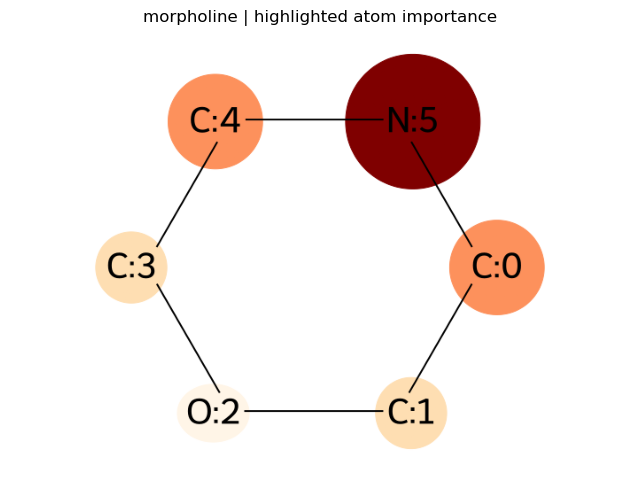

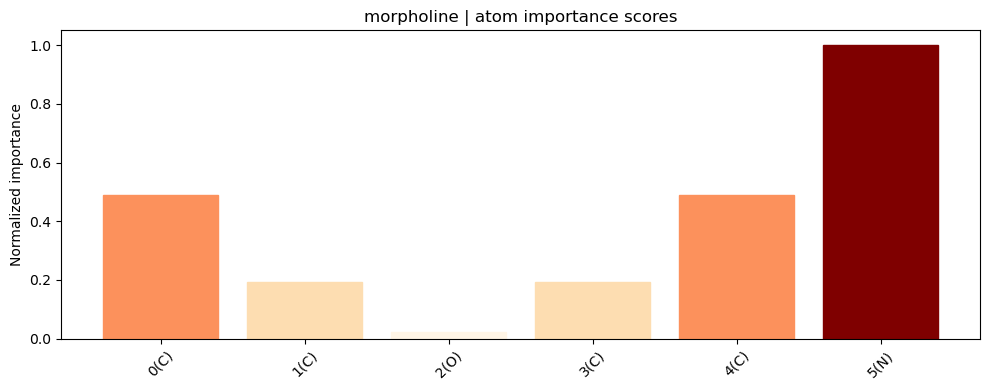

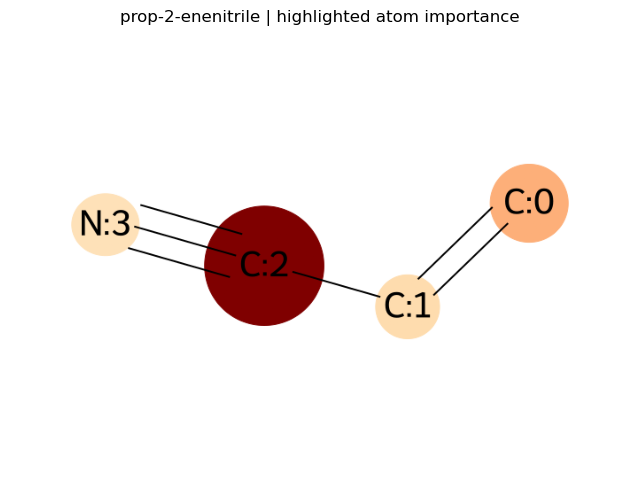

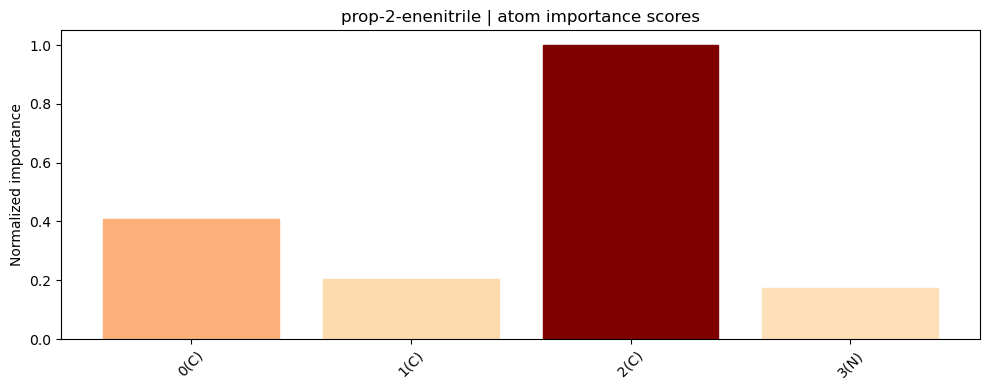

In [26]:
def find_matching_metadata_row(df_meta, graph_a, graph_b, true_target, tol=1e-6):
    """
    Find the metadata row whose SMILES atom counts match the graph node counts,
    and whose target is close to the true target.
    """
    n_a = graph_a.x.shape[0]
    n_b = graph_b.x.shape[0]

    candidate_rows = []

    for idx, row in df_meta.iterrows():
        smiles_a = row["SMILES_A"]
        smiles_b = row["SMILES_B"]

        mol_a = Chem.MolFromSmiles(smiles_a)
        mol_b = Chem.MolFromSmiles(smiles_b)

        if mol_a is None or mol_b is None:
            continue

        row_n_a = mol_a.GetNumAtoms()
        row_n_b = mol_b.GetNumAtoms()

        row_target = row["Target_neglog_molkg"] if "Target_neglog_molkg" in df_meta.columns else None

        if row_target is not None:
            target_match = abs(float(row_target) - float(true_target)) <= tol
        else:
            target_match = True

        if row_n_a == n_a and row_n_b == n_b and target_match:
            candidate_rows.append(idx)

    if len(candidate_rows) == 1:
        return candidate_rows[0]

    if len(candidate_rows) > 1:
        print("Multiple matching metadata rows found. Using first match.")
        return candidate_rows[0]

    print("No exact metadata match found. Falling back to target_idx row.")
    return None


def to_atom_importance(mol, importance):
    """
    Convert explanation output into one score per atom.
    """
    num_atoms = mol.GetNumAtoms()
    imp = np.asarray(importance, dtype=float)

    if imp.ndim == 2:
        if imp.shape[0] == num_atoms:
            return np.abs(imp).sum(axis=1)
        elif imp.shape[1] == num_atoms:
            return np.abs(imp).sum(axis=0)

    imp = imp.flatten()

    if len(imp) == num_atoms:
        return np.abs(imp)

    if len(imp) % num_atoms == 0:
        feat_dim = len(imp) // num_atoms
        return np.abs(imp.reshape(num_atoms, feat_dim)).sum(axis=1)

    raise ValueError(
        f"Cannot convert importance of length {len(imp)} to atom-level scores for molecule with {num_atoms} atoms."
    )


def normalize_atom_importance(atom_imp):
    atom_imp = np.asarray(atom_imp, dtype=float)
    if atom_imp.max() > 0:
        atom_imp = atom_imp / atom_imp.max()
    return atom_imp


def draw_molecule_with_importance(smiles, atom_importance, title="Molecule", width=700, height=500):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return

    atom_importance = normalize_atom_importance(atom_importance)

    cmap = cm.get_cmap("OrRd")
    atom_colors = {}
    atom_radii = {}

    for i, score in enumerate(atom_importance):
        rgba = cmap(float(score))
        atom_colors[i] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
        atom_radii[i] = 0.25 + 0.35 * float(score)

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = drawer.drawOptions()

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        opts.atomLabels[idx] = f"{atom.GetSymbol()}:{idx}"

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=list(atom_colors.keys()),
        highlightAtomColors=atom_colors,
        highlightAtomRadii=atom_radii
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    with open("temp_highlighted_mol.png", "wb") as f:
        f.write(png)

    img = plt.imread("temp_highlighted_mol.png")
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


def plot_atom_importance_bars(smiles, atom_importance, title="Atom importance"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return

    atom_importance = normalize_atom_importance(atom_importance)
    atom_labels = [f"{i}({mol.GetAtomWithIdx(i).GetSymbol()})" for i in range(len(atom_importance))]

    cmap = cm.get_cmap("OrRd")

    plt.figure(figsize=(10, 4))
    bars = plt.bar(range(len(atom_importance)), atom_importance)

    for i, b in enumerate(bars):
        b.set_color(cmap(float(atom_importance[i])))

    plt.xticks(range(len(atom_importance)), atom_labels, rotation=45)
    plt.ylabel("Normalized importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Prepare graph pair first

graph_a = prepare_single_graph(graphs_a_raw[target_idx], device)
graph_b = prepare_single_graph(graphs_b_raw[target_idx], device)

true_target = float(targets_raw[target_idx].item())
pred_target = predict_original(model, graph_a, graph_b, mixture_scaler)
toxicity_level = classify_toxicity_level(pred_target)

# Recompute explanation for this exact pair
imp_a_raw, imp_b_raw = best_explainer_fn(model, graph_a, graph_b, device)


# Find the correct metadata row

matched_idx = find_matching_metadata_row(df_meta, graph_a, graph_b, true_target)

if matched_idx is None:
    matched_idx = target_idx

smiles_a = df_meta.loc[matched_idx, "SMILES_A"]
smiles_b = df_meta.loc[matched_idx, "SMILES_B"]

drug_a_label = df_meta.loc[matched_idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else smiles_a
drug_b_label = df_meta.loc[matched_idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else smiles_b

mol_a = Chem.MolFromSmiles(smiles_a)
mol_b = Chem.MolFromSmiles(smiles_b)

print("Selected XAI method:", best_xai_method)
print("Matched metadata row:", matched_idx)
print("Drug A:", drug_a_label)
print("Drug B:", drug_b_label)
print("True mixture pLD50:", round(true_target, 4))
print("Predicted mixture pLD50:", round(pred_target, 4))
print("Predicted toxicity level:", toxicity_level)

print("\nGraph node count A:", graph_a.x.shape[0], "| SMILES atom count A:", mol_a.GetNumAtoms())
print("Graph node count B:", graph_b.x.shape[0], "| SMILES atom count B:", mol_b.GetNumAtoms())


# Convert explanation to atom-level importance

atom_imp_a = to_atom_importance(mol_a, imp_a_raw)
atom_imp_b = to_atom_importance(mol_b, imp_b_raw)


# Draw highlighted molecules

draw_molecule_with_importance(
    smiles_a,
    atom_imp_a,
    title=f"{drug_a_label} | highlighted atom importance"
)

plot_atom_importance_bars(
    smiles_a,
    atom_imp_a,
    title=f"{drug_a_label} | atom importance scores"
)

draw_molecule_with_importance(
    smiles_b,
    atom_imp_b,
    title=f"{drug_b_label} | highlighted atom importance"
)

plot_atom_importance_bars(
    smiles_b,
    atom_imp_b,
    title=f"{drug_b_label} | atom importance scores"
)

## Produce textual chemical explanation

In [27]:
def generate_textual_explanation(
    mol_a, mol_b,
    atom_imp_a, atom_imp_b,
    pred_value, toxicity_level,
    drug_a_label, drug_b_label,
    true_value=None,
    pairkey=None,
    top_k=3
):
    """
    Generate a human-readable explanation using:
    - top important atoms
    - important fragments
    - predicted toxicity
    """

    # Make sure these are atom-level scores
    atom_imp_a = np.asarray(atom_imp_a, dtype=float).flatten()
    atom_imp_b = np.asarray(atom_imp_b, dtype=float).flatten()

    # Top atoms
    top_idx_a, desc_a = get_top_atoms(mol_a, atom_imp_a, top_k=top_k)
    top_idx_b, desc_b = get_top_atoms(mol_b, atom_imp_b, top_k=top_k)

    # Important fragments
    frags_a = extract_important_fragments(mol_a, atom_imp_a)
    frags_b = extract_important_fragments(mol_b, atom_imp_b)

    frag_desc_a = [f"{frag_smiles} (atoms {atoms})" for atoms, frag_smiles in frags_a]
    frag_desc_b = [f"{frag_smiles} (atoms {atoms})" for atoms, frag_smiles in frags_b]

    true_line = f"Observed mixture toxicity (pLD50): {true_value:.4f}\n" if true_value is not None else ""
    pairkey_line = f"PairKey: {pairkey}\n" if pairkey is not None else ""

    explanation = f"""
--- Chemical Interpretation ---

{pairkey_line}Drug A: {drug_a_label}
Drug B: {drug_b_label}

{true_line}Predicted mixture toxicity (pLD50): {pred_value:.4f}
Toxicity level: {toxicity_level}

Key contributing atoms in Drug A:
- {"; ".join(desc_a)}

Key contributing atoms in Drug B:
- {"; ".join(desc_b)}

Important structural fragments in Drug A:
- {"; ".join(frag_desc_a) if frag_desc_a else "No strong fragment detected"}

Important structural fragments in Drug B:
- {"; ".join(frag_desc_b) if frag_desc_b else "No strong fragment detected"}

Interpretation:
The predicted toxicity appears to be influenced by specific atomic environments and substructures
within each molecule. The model gives higher importance to a limited set of atoms rather than the
whole molecule uniformly, suggesting that local structural features play a major role in the
predicted combined toxicity of the pair.
"""

    print(explanation)
    return explanation

## Save the target-pair explanation

Why this step matters
Stores the final explanation text for later reporting.

In [28]:
explanation_text = generate_textual_explanation(
    mol_a=mol_a,
    mol_b=mol_b,
    atom_imp_a=atom_imp_a,
    atom_imp_b=atom_imp_b,
    pred_value=pred_target,
    toxicity_level=toxicity_level,
    drug_a_label=drug_a_label,
    drug_b_label=drug_b_label,
    true_value=true_target,
    pairkey=df_meta.loc[matched_idx, "PairKey"] if "PairKey" in df_meta.columns else None,
    top_k=3
)

explanation_txt_path = os.path.join(processed_dir, "phase5_target_pair_explanation.txt")
with open(explanation_txt_path, "w", encoding="utf-8") as f:
    f.write(explanation_text)

print("Saved target-pair explanation to:", explanation_txt_path)


--- Chemical Interpretation ---

PairKey: C1COCCN1||C=CC#N
Drug A: morpholine
Drug B: prop-2-enenitrile

Observed mixture toxicity (pLD50): 2.1302
Predicted mixture toxicity (pLD50): 2.1963
Toxicity level: moderately toxic

Key contributing atoms in Drug A:
- ring N sp3 degree 2 1 H (atom 5); ring C sp3 degree 2 2 H (atom 4); ring C sp3 degree 2 2 H (atom 0)

Key contributing atoms in Drug B:
- C sp degree 2 (atom 2); C sp2 degree 1 2 H (atom 0); C sp2 degree 2 1 H (atom 1)

Important structural fragments in Drug A:
- N (atoms [5])

Important structural fragments in Drug B:
- C (atoms [2])

Interpretation:
The predicted toxicity appears to be influenced by specific atomic environments and substructures
within each molecule. The model gives higher importance to a limited set of atoms rather than the
whole molecule uniformly, suggesting that local structural features play a major role in the
predicted combined toxicity of the pair.

Saved target-pair explanation to: C:\Users\msi\Downloa

## Reusable function to explain any pair by index or name

In [29]:
def explain_pair(
    model,
    df_meta,
    graphs_a,
    graphs_b,
    scaler,
    device,
    explainer_fn,
    idx=None,
    pairkey=None,
    smiles_a=None,
    smiles_b=None,
    top_k=3,
    save_outputs=True,
    save_dir=None,
    show_plots=True
):
    """
    Explain any pair by:
    - direct row index
    - PairKey
    - SMILES_A + SMILES_B

    Also:
    - computes atom-level importance
    - generates text explanation
    - visualizes highlighted molecules and bar plots
    - saves outputs if requested

    Returns a dictionary with all important outputs.
    """

    idx = find_pair_index(
        df_meta,
        pairkey=pairkey,
        smiles_a=smiles_a,
        smiles_b=smiles_b,
        idx=idx
    )

    g_a = prepare_single_graph(graphs_a[idx], device)
    g_b = prepare_single_graph(graphs_b[idx], device)

    pred = predict_original(model, g_a, g_b, scaler)
    true_val = float(targets_raw[idx].item())
    toxicity_level = classify_toxicity_level(pred)

    imp_a_raw, imp_b_raw = explainer_fn(model, g_a, g_b, device)

    smiles_a_row = df_meta.loc[idx, "SMILES_A"]
    smiles_b_row = df_meta.loc[idx, "SMILES_B"]

    mol_a = Chem.MolFromSmiles(smiles_a_row)
    mol_b = Chem.MolFromSmiles(smiles_b_row)

    if mol_a is None or mol_b is None:
        raise ValueError("Invalid SMILES found in metadata.")

    atom_imp_a = to_atom_importance(mol_a, imp_a_raw)
    atom_imp_b = to_atom_importance(mol_b, imp_b_raw)

    atom_imp_a = normalize_atom_importance(atom_imp_a)
    atom_imp_b = normalize_atom_importance(atom_imp_b)

    drug_a_label = df_meta.loc[idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else smiles_a_row
    drug_b_label = df_meta.loc[idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else smiles_b_row

    pairkey_value = df_meta.loc[idx, "PairKey"] if "PairKey" in df_meta.columns else f"pair_{idx}"
    source_value = df_meta.loc[idx, "source"] if "source" in df_meta.columns else None

    _, desc_a = get_top_atoms(mol_a, atom_imp_a, top_k=top_k)
    _, desc_b = get_top_atoms(mol_b, atom_imp_b, top_k=top_k)

    explanation_text = generate_textual_explanation(
        mol_a=mol_a,
        mol_b=mol_b,
        atom_imp_a=atom_imp_a,
        atom_imp_b=atom_imp_b,
        pred_value=pred,
        toxicity_level=toxicity_level,
        drug_a_label=drug_a_label,
        drug_b_label=drug_b_label,
        true_value=true_val,
        pairkey=pairkey_value,
        top_k=top_k
    )

    saved_paths = {}

    if save_outputs:
        if save_dir is None:
            save_dir = os.path.join(processed_dir, "phase5_explanations")
        os.makedirs(save_dir, exist_ok=True)

        safe_pair_name = str(pairkey_value).replace("||", "__").replace("/", "_").replace("\\", "_").replace(":", "_")

        # Save text safely
        try:
            text_path = os.path.join(save_dir, f"{safe_pair_name}_explanation.txt")
            with open(text_path, "w", encoding="utf-8") as f:
                f.write(explanation_text)
            saved_paths["text_explanation"] = text_path
        except Exception as e:
            print(f"Warning: could not save text explanation for idx {idx}: {e}")
            saved_paths["text_explanation"] = None

    def save_highlighted_molecule(smiles, atom_importance, title, out_path=None, show=True):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        atom_importance = normalize_atom_importance(atom_importance)

        import matplotlib.cm as cm
        from rdkit.Chem.Draw import rdMolDraw2D

        cmap = cm.get_cmap("OrRd")
        atom_colors = {}
        atom_radii = {}

        for i, score in enumerate(atom_importance):
            rgba = cmap(float(score))
            atom_colors[i] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
            atom_radii[i] = 0.25 + 0.35 * float(score)

        drawer = rdMolDraw2D.MolDraw2DCairo(700, 500)
        opts = drawer.drawOptions()

        for atom in mol.GetAtoms():
            atom_idx = atom.GetIdx()
            opts.atomLabels[atom_idx] = f"{atom.GetSymbol()}:{atom_idx}"

        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer,
            mol,
            highlightAtoms=list(atom_colors.keys()),
            highlightAtomColors=atom_colors,
            highlightAtomRadii=atom_radii
        )
        drawer.FinishDrawing()

        png = drawer.GetDrawingText()

        if out_path is not None:
            with open(out_path, "wb") as f:
                f.write(png)

        if show:
            temp_path = out_path if out_path is not None else "temp_highlighted_mol.png"
            if out_path is None:
                with open(temp_path, "wb") as f:
                    f.write(png)

            img = plt.imread(temp_path)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(title)
            plt.show()

        return out_path

    def save_importance_barplot(smiles, atom_importance, title, out_path=None, show=True):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        atom_importance = normalize_atom_importance(atom_importance)

        import matplotlib.cm as cm
        cmap = cm.get_cmap("OrRd")
        atom_labels = [f"{i}({mol.GetAtomWithIdx(i).GetSymbol()})" for i in range(len(atom_importance))]

        plt.figure(figsize=(10, 4))
        bars = plt.bar(range(len(atom_importance)), atom_importance)

        for i, b in enumerate(bars):
            b.set_color(cmap(float(atom_importance[i])))

        plt.xticks(range(len(atom_importance)), atom_labels, rotation=45)
        plt.ylabel("Normalized importance")
        plt.title(title)
        plt.tight_layout()

        if out_path is not None:
            plt.savefig(out_path, dpi=300, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()

        return out_path

    if save_outputs:
        img_a_path = os.path.join(save_dir, f"{safe_pair_name}_drugA_highlight.png")
        img_b_path = os.path.join(save_dir, f"{safe_pair_name}_drugB_highlight.png")
        bar_a_path = os.path.join(save_dir, f"{safe_pair_name}_drugA_bars.png")
        bar_b_path = os.path.join(save_dir, f"{safe_pair_name}_drugB_bars.png")
    else:
        img_a_path = img_b_path = bar_a_path = bar_b_path = None

    # Save figures safely
    try:
        save_highlighted_molecule(
            smiles=smiles_a_row,
            atom_importance=atom_imp_a,
            title=f"{drug_a_label} | highlighted atom importance",
            out_path=img_a_path,
            show=show_plots
        )
        saved_paths["drugA_highlight"] = img_a_path
    except Exception as e:
        print(f"Warning: could not save Drug A highlight for idx {idx}: {e}")
        saved_paths["drugA_highlight"] = None

    try:
        save_importance_barplot(
            smiles=smiles_a_row,
            atom_importance=atom_imp_a,
            title=f"{drug_a_label} | atom importance scores",
            out_path=bar_a_path,
            show=show_plots
        )
        saved_paths["drugA_bars"] = bar_a_path
    except Exception as e:
        print(f"Warning: could not save Drug A bars for idx {idx}: {e}")
        saved_paths["drugA_bars"] = None

    try:
        save_highlighted_molecule(
            smiles=smiles_b_row,
            atom_importance=atom_imp_b,
            title=f"{drug_b_label} | highlighted atom importance",
            out_path=img_b_path,
            show=show_plots
        )
        saved_paths["drugB_highlight"] = img_b_path
    except Exception as e:
        print(f"Warning: could not save Drug B highlight for idx {idx}: {e}")
        saved_paths["drugB_highlight"] = None

    try:
        save_importance_barplot(
            smiles=smiles_b_row,
            atom_importance=atom_imp_b,
            title=f"{drug_b_label} | atom importance scores",
            out_path=bar_b_path,
            show=show_plots
        )
        saved_paths["drugB_bars"] = bar_b_path
    except Exception as e:
        print(f"Warning: could not save Drug B bars for idx {idx}: {e}")
        saved_paths["drugB_bars"] = None

    # Save summary safely
    if save_outputs:
        try:
            summary_path = os.path.join(save_dir, f"{safe_pair_name}_summary.json")
            summary_data = {
                "idx": int(idx),
                "pairkey": pairkey_value,
                "source": source_value,
                "drug_a_label": drug_a_label,
                "drug_b_label": drug_b_label,
                "smiles_a": smiles_a_row,
                "smiles_b": smiles_b_row,
                "true_pLD50": float(true_val),
                "pred_pLD50": float(pred),
                "toxicity_level": toxicity_level,
                "top_atoms_a": desc_a,
                "top_atoms_b": desc_b,
                "xai_method": best_xai_method
            }
            with open(summary_path, "w", encoding="utf-8") as f:
                json.dump(summary_data, f, indent=2)
            saved_paths["summary_json"] = summary_path
        except Exception as e:
            print(f"Warning: could not save summary json for idx {idx}: {e}")
            saved_paths["summary_json"] = None

    print(f"\n=== Explanation for pair index {idx} ===")
    print("Drug A:", drug_a_label)
    print("Drug B:", drug_b_label)
    print("PairKey:", pairkey_value)
    print("True mixture pLD50:", round(true_val, 4))
    print("Predicted mixture pLD50:", round(pred, 4))
    print("Predicted toxicity level:", toxicity_level)

    return {
        "idx": idx,
        "pairkey": pairkey_value,
        "source": source_value,
        "drug_a_label": drug_a_label,
        "drug_b_label": drug_b_label,
        "smiles_a": smiles_a_row,
        "smiles_b": smiles_b_row,
        "true_pLD50": true_val,
        "pred_pLD50": pred,
        "toxicity_level": toxicity_level,
        "top_atoms_a": desc_a,
        "top_atoms_b": desc_b,
        "explanation_text": explanation_text,
        "saved_paths": saved_paths
    }

## Save selected explanations for the benchmark subset

This gives you a compact CSV of example explanations across several unseen pairs.

In [30]:
rows = []

benchmark_save_dir = os.path.join(processed_dir, "phase5_benchmark_outputs")
os.makedirs(benchmark_save_dir, exist_ok=True)

for idx in benchmark_indices:
    try:
        result = explain_pair(
            model=model,
            df_meta=df_meta,
            graphs_a=graphs_a_raw,
            graphs_b=graphs_b_raw,
            scaler=mixture_scaler,
            device=device,
            explainer_fn=best_explainer_fn,
            idx=int(idx),
            top_k=3,
            save_outputs=True,
            save_dir=benchmark_save_dir,
            show_plots=False
        )

        rows.append({
            "idx": int(result["idx"]),
            "PairKey": result["pairkey"],
            "DrugA": result["drug_a_label"],
            "DrugB": result["drug_b_label"],
            "source": result["source"],
            "SMILES_A": result["smiles_a"],
            "SMILES_B": result["smiles_b"],
            "true_pLD50": result["true_pLD50"],
            "pred_pLD50": result["pred_pLD50"],
            "toxicity_level": result["toxicity_level"],
            "top_atoms_A": "; ".join(result["top_atoms_a"]),
            "top_atoms_B": "; ".join(result["top_atoms_b"]),
            "xai_method": best_xai_method,
            "text_path": result["saved_paths"].get("text_explanation"),
            "drugA_highlight_path": result["saved_paths"].get("drugA_highlight"),
            "drugB_highlight_path": result["saved_paths"].get("drugB_highlight"),
            "drugA_bars_path": result["saved_paths"].get("drugA_bars"),
            "drugB_bars_path": result["saved_paths"].get("drugB_bars"),
            "summary_json_path": result["saved_paths"].get("summary_json")
        })

    except Exception as e:
        print(f"Skipping idx {idx} due to error: {e}")

df_explanations = pd.DataFrame(rows)

selected_explanations_path = os.path.join(processed_dir, "phase5_selected_explanations.csv")
df_explanations.to_csv(selected_explanations_path, index=False)

print("Saved benchmark explanations to:", selected_explanations_path)
print("Number of saved rows:", len(df_explanations))

if len(df_explanations) > 0:
    display(df_explanations.head())
else:
    print("No rows were saved. Check earlier warnings/errors.")


--- Chemical Interpretation ---

PairKey: C1COCCN1||C=CC#N
Drug A: morpholine
Drug B: prop-2-enenitrile

Observed mixture toxicity (pLD50): 2.1302
Predicted mixture toxicity (pLD50): 2.1963
Toxicity level: moderately toxic

Key contributing atoms in Drug A:
- ring N sp3 degree 2 1 H (atom 5); ring C sp3 degree 2 2 H (atom 4); ring C sp3 degree 2 2 H (atom 0)

Key contributing atoms in Drug B:
- C sp degree 2 (atom 2); C sp2 degree 1 2 H (atom 0); C sp2 degree 2 1 H (atom 1)

Important structural fragments in Drug A:
- N (atoms [5])

Important structural fragments in Drug B:
- C (atoms [2])

Interpretation:
The predicted toxicity appears to be influenced by specific atomic environments and substructures
within each molecule. The model gives higher importance to a limited set of atoms rather than the
whole molecule uniformly, suggesting that local structural features play a major role in the
predicted combined toxicity of the pair.


=== Explanation for pair index 4 ===
Drug A: morpholi

,idx,PairKey,DrugA,DrugB,source,SMILES_A,SMILES_B,true_pLD50,pred_pLD50,toxicity_level,top_atoms_A,top_atoms_B,xai_method,text_path,drugA_highlight_path,drugB_highlight_path,drugA_bars_path,drugB_bars_path,summary_json_path
0,4,C1COCCN1||C=CC#N,morpholine,prop-2-enenitrile,Smyth,C1COCCN1,C=CC#N,2.130152,2.196291,moderately toxic,ring N sp3 degree 2 1 H (atom 5); ring C sp3 d...,C sp degree 2 (atom 2); C sp2 degree 1 2 H (at...,FeatureAblation,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
1,131,CC#N||Nc1ccccc1,acetonitrile,aniline,Smyth,CC#N,Nc1ccccc1,1.662592,1.807433,mildly toxic,N sp degree 1 (atom 2); C sp3 degree 1 3 H (at...,N sp2 degree 1 2 H (atom 0); aromatic C sp2 de...,FeatureAblation,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
2,172,CC(C)=O||CCOC(C)=O,propan-2-one,ethyl acetate,Smyth,CC(C)=O,CCOC(C)=O,0.854324,1.039506,very mildly toxic,C sp3 degree 1 3 H (atom 2); C sp3 degree 1 3 ...,C sp3 degree 1 3 H (atom 0); C sp2 degree 3 (a...,FeatureAblation,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
3,17,C1COCCN1||CCOC(C)=O,morpholine,ethyl acetate,Smyth,C1COCCN1,CCOC(C)=O,1.393190,1.410295,very mildly toxic,ring N sp3 degree 2 1 H (atom 5); ring C sp3 d...,C sp3 degree 1 3 H (atom 4); O sp2 degree 2 (a...,FeatureAblation,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
4,46,C1COCCO1||O=[N+]([O-])c1ccccc1,"1,4-dioxane",nitrobenzene,Smyth,C1COCCO1,O=[N+]([O-])c1ccccc1,2.151258,2.087506,moderately toxic,ring C sp3 degree 2 2 H (atom 3); ring C sp3 d...,O sp2 degree 1 charge -1 (atom 2); O sp2 degre...,FeatureAblation,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...


| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |
